In [1]:
import numpy as np
import pandas as pd
from google.colab import drive
import os
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP FINAL/ARCHIVOS')

Mounted at /content/drive


In [5]:
cant_archivos = int(len(os.listdir('/content/drive/MyDrive/Neurociencia Cognitiva/TP FINAL/ARCHIVOS'))/3)+1
print(cant_archivos)

posicion =[]
respuesta = []
tiempo = []

for i in range(1, cant_archivos):
    nombre_archivo = f'data7_{i}.csv'  #cambie el nombre
    df = pd.read_csv(nombre_archivo)

    posicion = list(posicion) + list(df.iloc[:, 2])
    respuesta = list(respuesta) + list(df.iloc[:, 3])#armo listas que contienen TODAS las respuestas de todos los archivos
    tiempo = list(tiempo) + list(df.iloc[:, 4])

print(len(respuesta), len(respuesta), len(tiempo))

rtas_corr = np.array([0]*7) #vector de cantidad de rtas correctas

for j in range(len(respuesta)):
        if  respuesta[j] == 1:            #miro solo las respuestas correctas
            rtas_corr[posicion[j]-1] += 1 #al vector de rtas correctas le sumo uno en la posicion de la letra
print(rtas_corr)

24
690 690 690
[47 46 53 47 55 66 63]


In [6]:
posiciones_suma = np.array([0]*7)
desvest_sumaal2 = np.array([0]*7)

for i in range(1, cant_archivos):
    nombre_archivo = f'data7_{i}.csv'
    df = pd.read_csv(nombre_archivo)

    posicion_i = list(df.iloc[:, 2])
    respuesta_i = list(df.iloc[:, 3])

    rtas_corr_i = np.array([0]*7) #en cada archivo cada vez que cambie de i vuelve a hacer la lista
    for j in range(30):
        if  respuesta_i[j] == 1:
            rtas_corr_i[posicion_i[j]-1] += 1
    #print(rtas_corr_i)

    #dsp del ultimo paso ya tengo el array rtas_corr_i que tiene la cantidad de rtas correctas por posicion del archivo i.
    promedio_i = (rtas_corr_i/3) #CAMBIE EL 3 POR UN 2
    #print(promedio_i)
    posiciones_suma = posiciones_suma + promedio_i #despues voy a promediar los promedios de todos los archivos y pasarlo a porcentaje entonces aca los voy sumando y a lo ultimo voy a dividir por cant_archivos

    devest_i = [] #ahora voy a sacar las desvest por pos de cada archivo i
    for k in range(len(rtas_corr_i)):
        if rtas_corr_i[k] == 0 or rtas_corr_i[k] == 3:
            devest_i.append(0)
        else:
            devest_i.append(0.471)
    #print(devest_i)
    desvest_sumaal2 = desvest_sumaal2 + np.array(devest_i)**2
    #print(desvest_sumaal2)

#ya afuera de todos los loops termino de calcular el prom y los errores

#print(posiciones_suma)
porcentajes_prom = (posiciones_suma/cant_archivos)*100
print(porcentajes_prom)

desvest_prom = (np.sqrt(desvest_sumaal2)/cant_archivos)*100
print(desvest_prom)

[65.27777778 63.88888889 73.61111111 65.27777778 76.38888889 91.66666667
 87.5       ]
[6.50887615 7.34300262 6.20596991 7.07589438 6.50887615 3.39914971
 3.39914971]


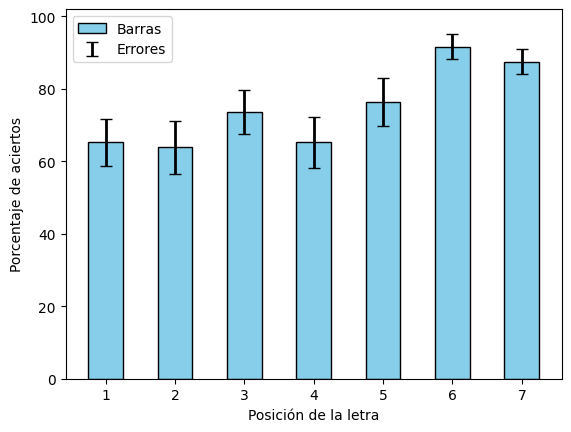

In [10]:
#ploteo
x = np.array(range(1,8))

plt.bar(x, porcentajes_prom, width = 0.5, color='skyblue', edgecolor='black', label='Barras') #gráfico de barras
plt.errorbar(x, porcentajes_prom, yerr=desvest_prom, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xlabel('Posición de la letra')
plt.ylabel('Porcentaje de aciertos')
plt.ylim(0,102)
plt.xticks(range(1, 8))
#plt.title('Respuestas correctas por posición')
plt.show()


In [8]:
prom3_1, prom3_2, prom3_3, prom3_4, prom3_5, prom3_6, prom3_7, prom3_8, prom3_9, prom3_10 = [],[],[],[],[],[],[],[],[],[] #promedio de las 3 rtas en cada posicion. prom3_k
dsv3_1, dsv3_2, dsv3_3, dsv3_4, dsv3_5, dsv3_6, dsv3_7, dsv3_8, dsv3_9, dsv3_10 = [],[],[],[],[],[],[],[],[],[] #dsv3_k

for i in range(1, cant_archivos): #leo cada archivo y nombro sus columnas
    nombre_archivo = f'data7_{i}.csv'
    df = pd.read_csv(nombre_archivo)
    posicion_i = list(df.iloc[:, 2])
    respuesta_i = list(df.iloc[:, 3])
    tiempo_i = list(df.iloc[:, 4])

    tiempo_en0_i = [] #normalizo los tiempos
    promedio_i = np.mean(tiempo_i)
    desvest_i = np.std(tiempo_i)
    for j in range(30):
        tiempo_en0_i.append((tiempo_i[j]-promedio_i)/desvest_i) #appendeo de una los 30 tiempos normalizados del archivo i


    for k in range (1, 7+1):
        t3_i_k = [] #lista para+ los 3 tiempos de las rtas por pos. Se vuelve a hacer cada que cambia k (CAMBIA A 2)
        t3_i_k.clear()
        for j in range(30):
            if posicion_i[j] == k:
                if respuesta_i[j] == 1: #cuando responden bien appendeo el tiempo correspondiente a la lista tik
                    t3_i_k.append(tiempo_en0_i[j])

        if len(t3_i_k) == 0:         #ARREGLADO: queda mal cuando no contestaron bien ninguna de las tres, tik queda vacio
            eval(f"prom3_{k}").append(0)
            eval(f"dsv3_{k}").append(0)
        else:
            eval(f"prom3_{k}").append(np.mean(t3_i_k)) #en prom_k guardo el promedio de las 3 rtas por posicion
            eval(f"dsv3_{k}").append(np.std(t3_i_k)/len(t3_i_k)) #guardo el errores de estos promedios

        #print("Datos contienen NaNs:", np.any(np.isnan(prom3_1)))

#hasta aca hice el primedio por persona/archivo del tiempo en cada una delas 10 posiciones.
#queda promediar los tiempos de todos los archivos, por posicion

prom_t_tot = []
err_t_tot = []

for k in range (1, 7+1):
    prom_t_tot.append(np.mean(eval(f"prom3_{k}"))) #hago el promedio de los promedios en cada posicion k
    dsv_array = np.array(eval(f"dsv3_{k}")) #paso a array las dsv
    err_t_tot.append(np.sqrt(sum(dsv_array**2))/cant_archivos) #el error del prom

print(prom_t_tot)
print(err_t_tot)

[-0.03447996257467079, -0.01663129356894124, 0.03156443704808675, -0.11845855116183573, -0.30162242897418534, -0.21683794619512636, -0.5009422720694794]
[0.03824382005698691, 0.04216336240950833, 0.04837724922145431, 0.04512762288719985, 0.04124237386811544, 0.06119657282417088, 0.0376727167299035]


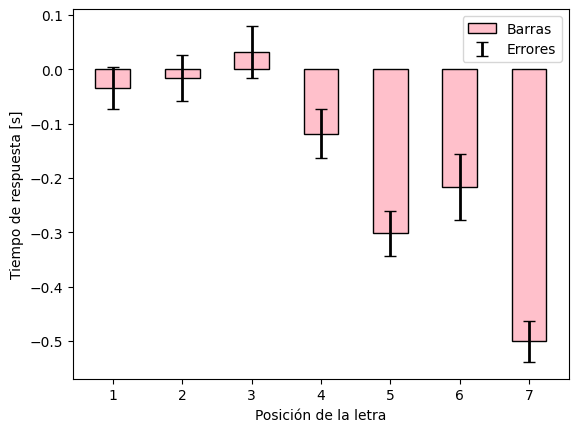

In [11]:
#ploteo
plt.bar(x, prom_t_tot, width = 0.5, color='pink', edgecolor='black', label='Barras') #gráfico derrorbare barras
plt.xlabel('Posición de la letra')
plt.ylabel('Tiempo de respuesta [s]')
plt.errorbar(x, prom_t_tot, yerr=err_t_tot, fmt='none', ecolor='black', elinewidth=2, capsize=4, label='Errores')
plt.legend()
plt.xticks(range(1, 8))
#plt.title('Tiempos de respuesta por posición')
plt.show()